In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib openpyxl

In [ ]:
#Cell1—Importlibraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as sticker

#This formatter will make y-axisshowrealnumberslike$25,000,000
#insteadofscientificnotationlike2.5e7

money_fmt = sticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

print('Ready!')

Ready!


In [ ]:
#Cell2—Loadthedataset
df = pd.read_excel('finance_transactions_dataset.xlsx')

#Quickcheck:howmanyrowsandcolumns?

print(df.shape)#e.g.(1000,14)
print(df.columns.tolist())

(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [ ]:

#cell 3b
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


In [ ]:
# Cell 3a
df.head()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst
0,TXN1001,GreenEnergy,Energy,Marketing,Loan Repayment,NaN,104037.35,0.09,9363.36,94673.99,USD,2022-05-24,Pending,Analyst_B
1,TXN1002,LogiTrans,Logistics,IT,Loan Repayment,NaN,431438.64,0.10,43143.86,388294.78,USD,2023-08-04,Pending,Analyst_D
2,TXN1003,EduGroup,Education,Sales,Investment,NaN,494837.13,0.18,89070.68,405766.45,GBP,2023-08-05,Rejected,Analyst_B
3,TXN1004,HealthPlus,Healthcare,Sales,Revenue,NaN,59347.25,0.09,5341.25,54006.00,USD,2024-11-01,Pending,Analyst_A
4,TXN1005,EduGroup,Education,Finance,Loan Repayment,NaN,132500.40,0.15,19875.06,112625.34,GBP,2021-09-16,Approved,Analyst_C


In [ ]:
df.tail()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst,TransactionDate,Year,Month
994,TXN1995,TechCorp,Technology,Sales,Revenue,N/A,328157.17,0.23,75476.15,252681.02,EUR,2024-06-24,Rejected,Analyst_A,2024-06-24,2024,2024-06
995,TXN1996,MediaMax,Media,Unknown,Revenue,N/A,131928.04,0.14,18469.93,113458.11,USD,2024-07-27,Approved,Analyst_B,2024-07-27,2024,2024-07
996,TXN1997,HealthPlus,Healthcare,Marketing,Revenue,N/A,395637.83,0.28,110778.59,284859.24,GBP,2024-03-31,Approved,Analyst_C,2024-03-31,2024,2024-03
997,TXN1998,TechCorp,Technology,IT,Loan Repayment,N/A,404246.71,0.22,88934.28,315312.43,USD,2021-06-03,Approved,Analyst_C,2021-06-03,2021,2021-06
999,TXN2000,RetailHub,Retail,Sales,Investment,N/A,65608.33,0.06,3936.50,61671.83,NGN,2024-10-27,Pending,Analyst_A,2024-10-27,2024,2024-10


In [ ]:
#Cell3c
df.describe().round(2)

,Amount,Tax_Rate,Tax_Amount,Net_Amount
count,961.00,1000.00,1000.00,960.00
mean,248309.09,0.18,44196.90,203859.56
std,145329.13,0.07,33447.57,120727.44
min,5132.61,0.05,355.38,3644.15
25%,115322.10,0.12,16896.31,94843.24
50%,250121.30,0.18,35780.50,200693.33
75%,375654.46,0.24,66364.00,308532.69
max,499771.64,0.30,148757.97,454365.87


In [ ]:
#Cell 3d
df.isnull().sum()

,0
Transaction_ID,0
Company,44
Sector,0
Department,54
Transaction_Type,0
Category,789
Amount,39
Tax_Rate,0
Tax_Amount,0
Net_Amount,40


In [ ]:

#Cell 4a
#Remove rows where essential columns are empty

df.dropna(subset=['Amount','Net_Amount','Transaction_Date',
'Approval_Status'], inplace=True)
print('Rows remaining:',len(df))

Rows remaining: 845


In [ ]:
#Cell 4b
#Fill gaps in text columns
df['Company']= df['Company'].fillna('Unknown')
df['Department']=df['Department'].fillna('Unknown')
df['Analyst']= df['Analyst'].fillna('Unknown')
df['Category']= df['Category'].fillna('N/A')

In [ ]:
#Cell4c
# Turn text dates into proper dates,then extract Year and Month
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'],errors='coerce')
df.dropna(subset=['Transaction_Date'],inplace=True)

df['Year']=df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)

print('Sample dates:')
print(df[['Transaction_Date','Year','Month']].head(3))

Sample dates:
  Transaction_Date  Year    Month
0       2022-05-24  2022  2022-05
1       2023-08-04  2023  2023-08
2       2023-08-05  2023  2023-08


In [ ]:
#Cell4d
df.drop_duplicates(inplace=True)
print('Final row count:',len(df))

Final row count: 845


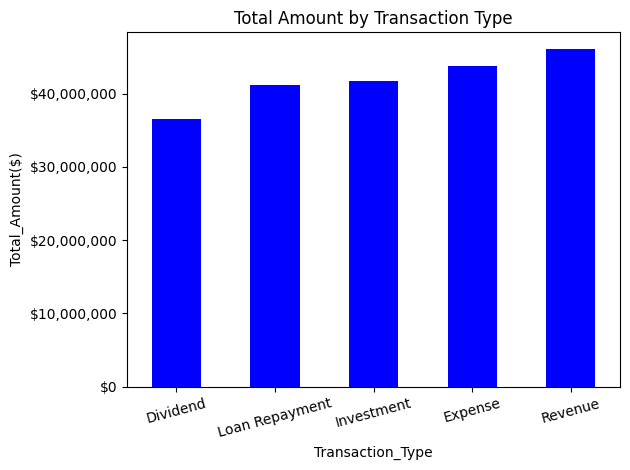

In [ ]:
#Cell 5a Barchart
df.groupby('Transaction_Type')['Amount'].sum().sort_values().plot(kind='bar',
color='blue')
plt.title('Total Amount by Transaction Type')
plt.gca().yaxis.set_major_formatter(money_fmt) #show real numbers,not b2.5e7
plt.ylabel('Total_Amount($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

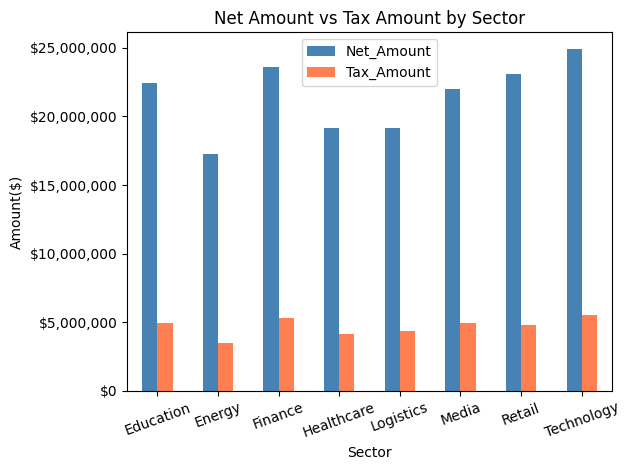

In [ ]:

#How much tax does each sector pay vs what it keeps?
#Cell 5b-Grouped bar chart
df.groupby('Sector')[['Net_Amount','Tax_Amount']].sum().plot(kind='bar', color=['steelblue','coral'])
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt) #show real numbers,not 2.5e7
plt.tight_layout()
plt.show()

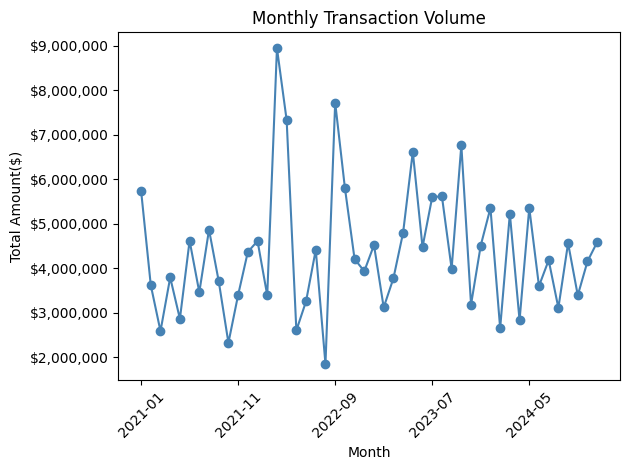

In [ ]:
#Cell 5c—Line chart
df.groupby('Month')['Amount'].sum().plot(kind='line',marker='o',color='steelblue')
plt.title('Monthly Transaction Volume')
plt.ylabel('Total Amount($)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(money_fmt) #show real numbers,not 2.5e7
plt.tight_layout()
plt.show()

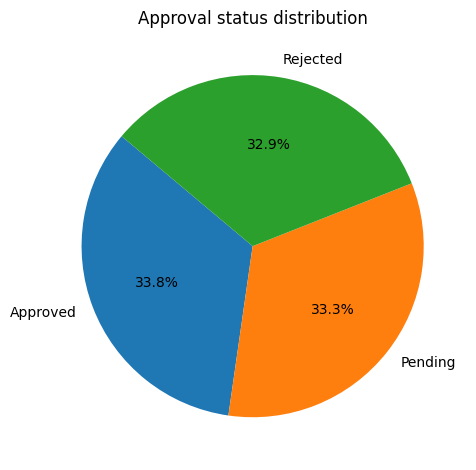

In [ ]:
#Cell 5d—Pie chart
df['Approval_Status'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=140)
plt.title('Approval status distribution')
plt.ylabel('') #hides the defaulty-axis label on pie charts
plt.tight_layout()
plt.show()

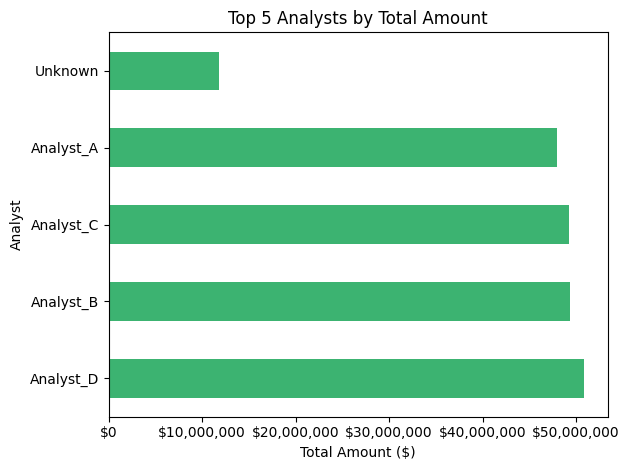

In [ ]:
#Cell 5e—Horizontal bar chart
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh',color='mediumseagreen')
plt.gca().xaxis.set_major_formatter(money_fmt)#xaxisforhorizontalbars
plt.title('Top 5 Analysts by Total Amount')
plt.xlabel('Total Amount ($)')
plt.tight_layout()
plt.show()

In [ ]:
#Cell 6 Summary
print('='*46)
print('FINANCE DATASET SUMMARY')
print('='*46)
print(f"Transactions:{len(df):,}")
print(f"Total Amount: ${df['Amount'].sum():,.0f}")
print(f"Total Tax Paid:${df['Tax_Amount'].sum():,.0f}")
print(f"Total Net Amount:${df['Net_Amount'].sum():,.0f}")
print(f"Avg Tax Rate:{df['Tax_Rate'].mean()*100:.1f}%")
print(f"Approval Rate:{(df['Approval_Status']=='Approved').mean()*100:.1f}%")
print(f"Top Sector: {df.groupby('Sector')['Amount'].sum().idxmax()}")
print(f"Top  Analyst:{df.groupby('Analyst')
['Amount'].sum().idxmax()}")
print('='*46)

FINANCE DATASET SUMMARY
Transactions:845
Total Amount: $209,284,457
Total Tax Paid:$37,622,745
Total Net Amount:$171,661,713
Avg Tax Rate:17.9%
Approval Rate:33.8%
Top Sector: Technology
Top  Analyst:Analyst_D


Text(0, 0.5, 'Department')

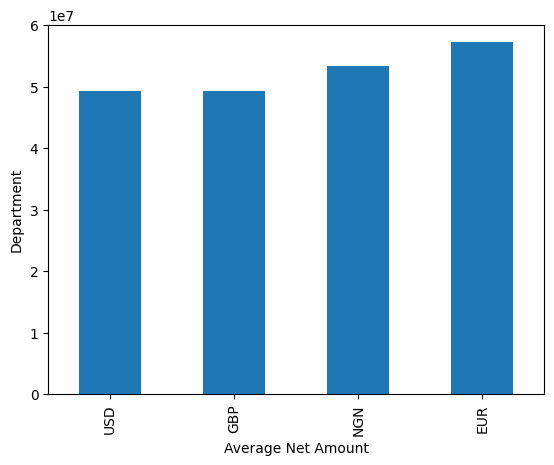

In [ ]:
#challenge
df.groupby('Currency')['Amount'].sum().sort_values().plot(kind='bar')
plt.xlabel('Average Net Amount')

Text(0, 0.5, 'Net Amount')

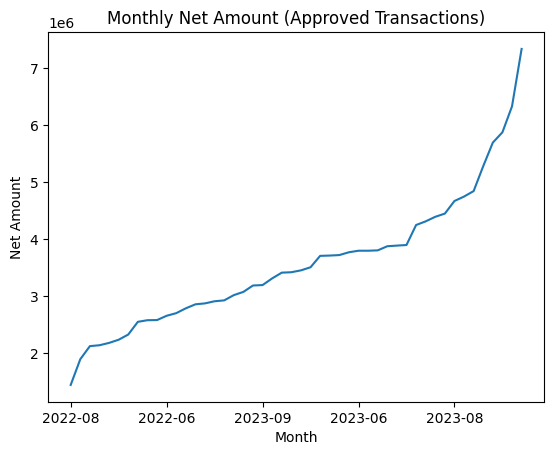

In [ ]:
approved_df = df[df['Approval_Status'] == 'Approved']
df.groupby('Month')['Net_Amount'].sum().sort_values().plot(kind='line')plt.title('Monthly Net Amount (Approved Transactions)')
plt.ylabel('Net Amount')

Text(0.5, 0, 'Net Amount')

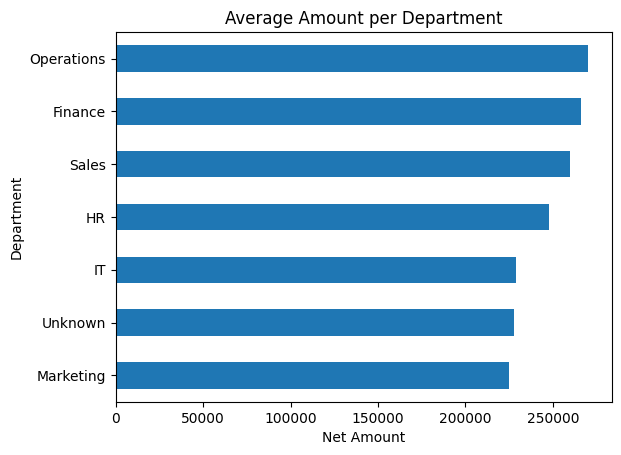

In [ ]:
df.groupby('Department')['Amount'].mean().sort_values().plot(kind='barh')
plt.title('Average Amount per Department')
plt.xlabel('Net Amount')

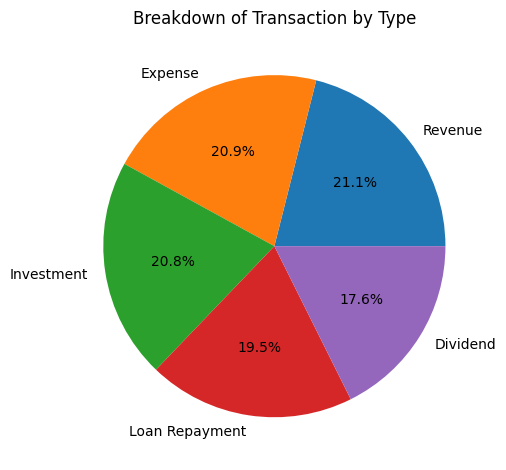

In [ ]:
df['Transaction_Type'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Breakdown of Transaction by Type')
plt.ylabel('') #hides the defaulty-axis label on pie charts
plt.tight_layout()
plt.show()

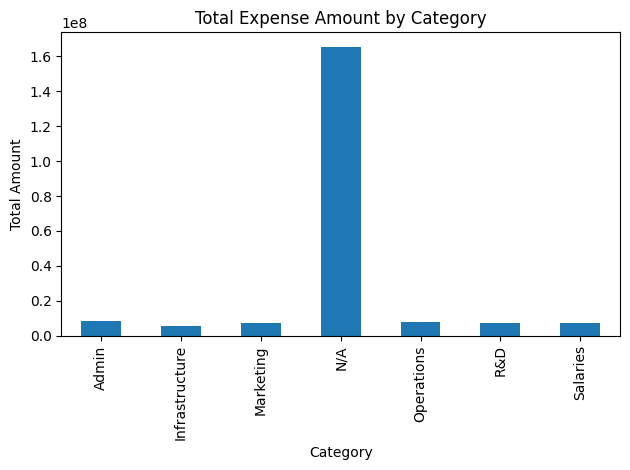

In [ ]:
df[df['Transaction_Type'] == 'Expense']
df.groupby('Category')['Amount'].sum().plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.title('Total Expense Amount by Category')
plt.tight_layout()
plt.show()